# Chương 4. Mạng nơ-ron hồi quy (RNN)

Cùng bài toán với Chương 3 nhưng mạng đọc trực tiếp chuỗi 20 lợi suất logarit. Mô hình đại diện là LSTM, so sánh thêm SimpleRNN, GRU, hai đường cơ sở và backtest có phí giao dịch.

Notebook đọc dữ liệu đã xử lý tại `data/tieuluan/processed` và kết quả đã lưu tại `results/tieuluan/full`
(sinh bởi `scripts/tieuluan/run_experiments.py`). Mục 3 **huấn luyện lại ngay trong notebook** cùng một cấu
hình bằng ba cách cài đặt để đối chiếu với kết quả đã lưu; mô hình huấn luyện lại chỉ nằm trong bộ nhớ,
không ghi đè file nào. Chạy bằng **Restart Kernel → Run All**.

In [1]:
import os, sys, json, inspect
from pathlib import Path
for name in ('OMP_NUM_THREADS', 'OPENBLAS_NUM_THREADS', 'MKL_NUM_THREADS', 'NUMEXPR_NUM_THREADS'):
    os.environ.setdefault(name, '2')          # cùng điều kiện với scripts/tieuluan/run_experiments.py
os.environ.setdefault('TF_CPP_MIN_LOG_LEVEL', '3')
os.environ.setdefault('KERAS_BACKEND', 'tensorflow')
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'src/tieuluan/experiment_models.py').exists())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.metrics import roc_auc_score
from src.tieuluan.config import ANALYSIS_START
from src.tieuluan.experiment_models import build_models, fit_model, predict_logits

PROCESSED = ROOT / 'data/tieuluan/processed'
RESULTS = ROOT / 'results/tieuluan/full'
inventory = json.loads((PROCESSED / 'inventory.json').read_text(encoding='utf-8'))
analysis = json.loads((RESULTS / 'analysis.json').read_text(encoding='utf-8'))
records = [json.loads(p.read_text(encoding='utf-8')) for p in sorted(RESULTS.glob('*__*.json'))]
NAMES = {'taiwan_bankruptcy': 'Phá sản DN (UCI 572)', 'credit_default': 'Vỡ nợ thẻ (UCI 350)',
         'sp500': 'S&P 500', 'vnindex': 'VN-Index', 'btc': 'Bitcoin'}
FW = {'scratch': 'NumPy tự viết', 'pytorch': 'PyTorch', 'keras': 'Keras', 'sklearn': 'scikit-learn', 'baseline': 'Đường cơ sở'}
sigmoid = lambda z: .5 * (1 + np.tanh(np.asarray(z, dtype=float) / 2))
print('Số bản ghi thực nghiệm đã lưu:', len(records))

Số bản ghi thực nghiệm đã lưu: 128


In [2]:
DATASETS = ['sp500', 'vnindex', 'btc']
KIND = 'lstm'
KINDS = ['rnn', 'lstm', 'gru', 'persistence', 'majority']
REPRESENTATION = 'sequence'
DEMO = 'vnindex'

## 1. Dữ liệu

Kích thước và phân bố lớp đọc trực tiếp từ mảng đã lưu (không chép tay). Bộ tiền xử lý (chuẩn hóa,
điền khuyết) chỉ học trên tập train rồi áp dụng nguyên cho validation và test.

In [3]:
data = {}
rows = []
for name in DATASETS:
    with np.load(PROCESSED / f'{name}.npz', allow_pickle=False) as archive:
        data[name] = {key: archive[key] for key in archive.files}
    for split in ('train', 'val', 'test'):
        y = data[name][f'{split}_y']
        assert len(y) == inventory[name]['splits'][split]['n']          # khớp số liệu đã kiểm kê
        rows.append({'Bộ dữ liệu': NAMES[name], 'Tập': split, 'Số mẫu': len(y), 'Lớp 0': int((y == 0).sum()),
                     'Lớp 1': int((y == 1).sum()), 'Tỉ lệ lớp 1': round(float(y.mean()), 4),
                     'Kích thước đầu vào': str(data[name][f'{split}_{REPRESENTATION}'].shape[1:])})
display(pd.DataFrame(rows))

,Bộ dữ liệu,Tập,Số mẫu,Lớp 0,Lớp 1,Tỉ lệ lớp 1,Kích thước đầu vào
0,S&P 500,train,5010,2327,2683,0.5355,"(20, 1)"
1,S&P 500,val,755,360,395,0.5232,"(20, 1)"
2,S&P 500,test,938,418,520,0.5544,"(20, 1)"
3,VN-Index,train,2473,1155,1318,0.5330,"(20, 1)"
4,VN-Index,val,750,318,432,0.5760,"(20, 1)"
5,VN-Index,test,929,408,521,0.5608,"(20, 1)"
6,Bitcoin,train,1911,866,1045,0.5468,"(20, 1)"
7,Bitcoin,val,1095,533,562,0.5132,"(20, 1)"
8,Bitcoin,test,1368,682,686,0.5015,"(20, 1)"


**Dòng dữ liệu gốc và kiểm tra ranh giới thời gian.** Train gồm các mẫu có ngày nhãn đến hết 2019, validation
2020–2022, test từ 01/2023 đến 30/09/2026; mẫu có nhãn vượt sang tập sau bị loại. Ô dưới kiểm tra lại điều đó.

In [4]:
for name in DATASETS:
    raw = pd.read_csv(ROOT / f'data/tieuluan/raw/indices/{name}.csv')
    raw = raw[raw.date >= ANALYSIS_START[name]]
    print(f"{NAMES[name]}: {len(raw)} phiên từ {raw.date.iloc[0]} đến {raw.date.iloc[-1]}")
    display(raw.head(3))
    arrays = data[name]
    assert arrays['train_target_date'].max() <= np.datetime64('2019-12-31')
    assert arrays['val_date'].min() >= np.datetime64('2020-01-01')
    assert arrays['val_target_date'].max() <= np.datetime64('2022-12-31')
    assert arrays['test_date'].min() >= np.datetime64('2023-01-01')
    assert arrays['test_target_date'].max() <= np.datetime64('2026-09-30')
print('Đã kiểm tra: không mẫu nào có nhãn vượt ranh giới giữa các tập.')

S&P 500: 6726 phiên từ 2000-01-03 đến 2026-09-30


,date,open,high,low,close,volume,source
0,2000-01-03,1469.250000,1478.000000,1438.359985,1455.219971,931800000,Yahoo Finance
1,2000-01-04,1455.219971,1455.219971,1397.430054,1399.420044,1009000000,Yahoo Finance
2,2000-01-05,1399.420044,1413.270020,1377.680054,1402.109985,1085500000,Yahoo Finance


VN-Index: 4175 phiên từ 2010-01-04 đến 2026-09-30


,date,open,high,low,close,volume,source
2192,2010-01-04,501.7,517.1,501.7,517.1,42051600,SSI iBoard
2193,2010-01-05,538.8,539.4,530.2,532.5,66619450,SSI iBoard
2194,2010-01-06,527.4,538.8,526.4,534.5,64222280,SSI iBoard


Bitcoin: 4397 phiên từ 2014-09-17 đến 2026-09-30


,date,open,high,low,close,volume,source
0,2014-09-17,465.864014,468.174011,452.421997,457.334015,21056800,Yahoo Finance
1,2014-09-18,456.859985,456.859985,413.104004,424.440002,34483200,Yahoo Finance
2,2014-09-19,424.102997,427.834991,384.532013,394.795990,37919700,Yahoo Finance


Đã kiểm tra: không mẫu nào có nhãn vượt ranh giới giữa các tập.


**Chuỗi lợi suất.** Đầu vào của mạng hồi quy là 20 lợi suất logarit gần nhất, chuẩn hóa bằng trung bình và độ
lệch chuẩn của tập train. Biểu đồ khôi phục về đơn vị phần trăm để dễ đọc.

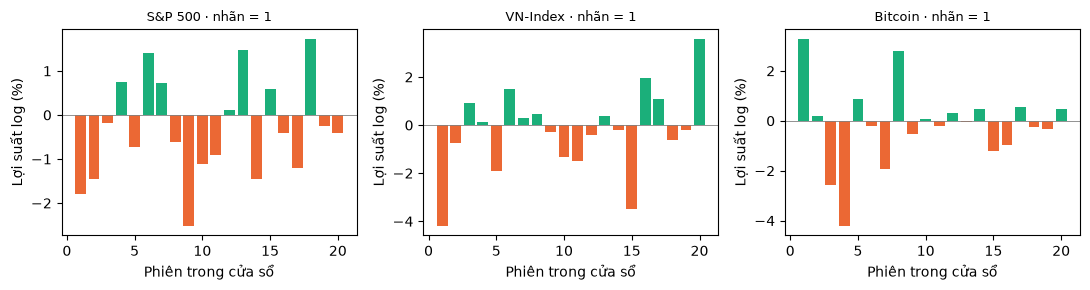

In [5]:
fig, axes = plt.subplots(1, len(DATASETS), figsize=(11, 3))
for ax, name in zip(axes, DATASETS):
    arrays = data[name]
    r = arrays['test_sequence'][0, :, 0] * arrays['scaler_scale'][0] + arrays['scaler_mean'][0]
    ax.bar(np.arange(1, 21), 100 * r, color=np.where(r > 0, '#1baf7a', '#eb6834'))
    ax.axhline(0, color='gray', lw=.6)
    ax.set_title(f"{NAMES[name]} · nhãn = {int(arrays['test_y'][0])}", fontsize=9)
    ax.set_xlabel('Phiên trong cửa sổ'); ax.set_ylabel('Lợi suất log (%)')
plt.tight_layout(); plt.show()

## 2. Một mô hình, ba cách cài đặt

Mã nguồn đầy đủ nằm trong `src/tieuluan/experiment_models.py` (hàm `scratch_model`, `torch_model`, `keras_model`)
và thư viện tự viết `src/tieuluan/scratch/`. Ô dưới in phần định nghĩa mô hình của ba hàm, rồi khởi tạo cả ba
bản bằng **cùng một bộ trọng số NumPy** và so sánh logit đầu ra trên vài mẫu (chưa huấn luyện).

In [6]:
import src.tieuluan.experiment_models as em
for fn in (em.scratch_model, em.torch_model, em.keras_model):
    print(inspect.getsource(fn))

def scratch_model(kind, input_shape, seed):
    rng = np.random.default_rng(seed)
    if kind == "mlp":
        return Sequential(Dense(input_shape[0], 16, rng=rng), ReLU(), Dense(16, 1, rng=rng))
    if kind in ("cnn4", "cnn8"):
        filters = 8 if kind == "cnn8" else 4
        return Sequential(Conv2d(1, filters, 3, rng=rng), ReLU(), MaxPool2d(2),       # 20 → 18 → 9
                          Flatten(), Dense(filters * 9 * 9, 1, rng=rng))
    if kind == "cnndeep":
        return Sequential(Conv2d(1, 4, 3, rng=rng), ReLU(), MaxPool2d(2),             # 20 → 18 → 9
                          Conv2d(4, 8, 3, rng=rng), ReLU(), MaxPool2d(2),             # 9 → 7 → 3
                          Flatten(), Dense(8 * 3 * 3, 1, rng=rng))
    cell = {"rnn": SimpleRNN, "lstm": LSTM, "gru": GRU}[kind]
    return Sequential(cell(input_shape[-1], HIDDEN, rng=rng), LastStep(), Dense(HIDDEN, 1, rng=rng))

def torch_model(kind, input_shape):
    import torch
    from torch import nn

    torch.set_num_

In [7]:
sample = data[DEMO]['train_' + REPRESENTATION][:8].astype(np.float32)
models = build_models(KIND, sample.shape[1:], seed=11)
logits = {FW[f]: predict_logits(m, f, sample) for f, m in models.items()}
display(pd.DataFrame(logits).round(6))
base = logits['NumPy tự viết']
print({k: float(np.max(np.abs(v - base))) for k, v in logits.items()}, '← lệch tuyệt đối lớn nhất so với NumPy')

,NumPy tự viết,PyTorch,Keras
0,0.091025,0.091025,0.091025
1,0.070543,0.070543,0.070543
2,-0.000623,-0.000623,-0.000623
3,-0.051960,-0.051960,-0.051960
4,0.145073,0.145073,0.145073
5,0.129251,0.129251,0.129251
6,0.168839,0.168839,0.168839
7,0.100390,0.100390,0.100390


{'NumPy tự viết': 0.0, 'PyTorch': 4.470348358154297e-08, 'Keras': 2.2351741790771484e-08} ← lệch tuyệt đối lớn nhất so với NumPy


## 3. Huấn luyện lại bằng ba cách (vnindex, hạt giống 11)

Cả ba bản dùng cùng trọng số khởi tạo, cùng thứ tự mini-batch (batch 64), Adam với tốc độ học 0,001, cắt chuẩn
gradient ở 1,0, tối đa 60 epoch và dừng sớm sau 8 epoch không cải thiện BCE trên validation. Bảng so sánh ROC-AUC
vừa huấn luyện với giá trị đã lưu: bản NumPy và PyTorch thường trùng tới nhiều chữ số; Keras có thể lệch rất nhỏ do
cách đặt hằng số ε của Adam và thứ tự phép tính.

,Cài đặt,Epoch tốt nhất,Số epoch đã chạy,Giây,ROC-AUC vừa huấn luyện,ROC-AUC đã lưu,Lệch xác suất tối đa so với file đã lưu
0,NumPy tự viết,8,16,1.5,0.54554,0.54554,0.0
1,PyTorch,8,16,1.8,0.54554,0.54554,0.0
2,Keras,8,16,6.8,0.54553,0.54553,0.0


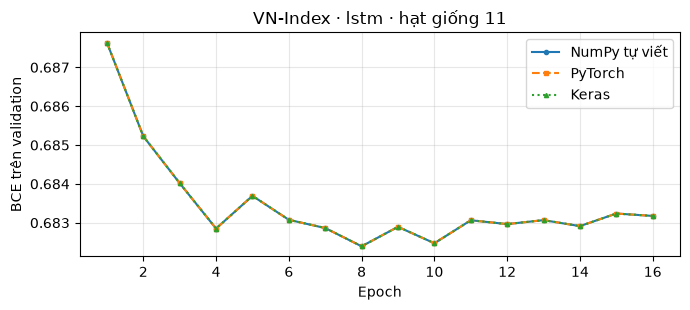

In [8]:
x, y = data[DEMO]['train_' + REPRESENTATION], data[DEMO]['train_y']
xv, yv = data[DEMO]['val_' + REPRESENTATION], data[DEMO]['val_y']
xt, yt = data[DEMO]['test_' + REPRESENTATION], data[DEMO]['test_y']
saved = {r['framework']: r for r in records if r['dataset'] == DEMO and r['kind'] == KIND and r['seed'] == 11}
rows, curves = [], {}
for framework in ('scratch', 'pytorch', 'keras'):
    model = build_models(KIND, x.shape[1:], seed=11, frameworks=(framework,))[framework]
    fit = fit_model(model, framework, KIND, x, y, xv, yv, seed=11, epochs=60, batch_size=64, patience=8)
    p = sigmoid(predict_logits(model, framework, xt))
    with np.load(RESULTS / f'{DEMO}__{KIND}__{framework}__11_predictions.npz') as archive:
        p_saved = archive['probability']
    curves[framework] = [h['val_loss'] for h in fit['history']]
    rows.append({'Cài đặt': FW[framework], 'Epoch tốt nhất': fit['best_epoch'], 'Số epoch đã chạy': fit['epochs_run'],
                 'Giây': round(fit['training_seconds'], 1), 'ROC-AUC vừa huấn luyện': round(roc_auc_score(yt, p), 5),
                 'ROC-AUC đã lưu': round(saved[framework]['metrics']['roc_auc'], 5),
                 'Lệch xác suất tối đa so với file đã lưu': float(np.max(np.abs(p - p_saved)))})
display(pd.DataFrame(rows))
fig, ax = plt.subplots(figsize=(7, 3.2))
for (framework, values), style in zip(curves.items(), ('-o', '--s', ':^')):
    ax.plot(range(1, len(values) + 1), values, style, ms=3, label=FW[framework])
ax.set_xlabel('Epoch'); ax.set_ylabel('BCE trên validation'); ax.set_title(f'{NAMES[DEMO]} · {KIND} · hạt giống 11')
ax.grid(alpha=.3); ax.legend(); plt.tight_layout(); plt.show()

## 4. Kết quả đầy đủ (3 hạt giống) và khoảng tin cậy

Bảng dưới tổng hợp các bản ghi đã lưu của chương (trung bình và độ lệch chuẩn qua 3 hạt giống), tiếp theo là
khoảng tin cậy 95% của ROC-AUC cho dự báo trung bình 3 hạt giống.

In [9]:
rows = []
for r in records:
    if r['dataset'] in DATASETS and r['kind'] in KINDS:
        rows.append({'Bộ dữ liệu': NAMES[r['dataset']], 'Mô hình': r['kind'], 'Cài đặt': FW[r['framework']],
                     'roc_auc': r['metrics']['roc_auc'], 'balanced_accuracy': r['metrics']['balanced_accuracy']})
table = (pd.DataFrame(rows).groupby(['Bộ dữ liệu', 'Mô hình', 'Cài đặt'])
         .agg(ROC_AUC_TB=('roc_auc', 'mean'), ROC_AUC_ĐLC=('roc_auc', 'std'),
              Balanced_acc=('balanced_accuracy', 'mean'), Số_lượt=('roc_auc', 'size')).round(4))
display(table)

ROC_AUC_TB  ROC_AUC_ĐLC  Balanced_acc  \
Bộ dữ liệu Mô hình     Cài đặt                                                
Bitcoin    gru         PyTorch            0.5172       0.0079        0.5051   
           lstm        Keras              0.5047       0.0214        0.5069   
                       NumPy tự viết      0.5047       0.0214        0.5069   
                       PyTorch            0.5047       0.0214        0.5069   
           majority    Đường cơ sở        0.5000          NaN        0.5000   
           persistence Đường cơ sở        0.4846          NaN        0.4846   
           rnn         PyTorch            0.5106       0.0039        0.5162   
S&P 500    gru         PyTorch            0.4904       0.0011        0.4909   
           lstm        Keras              0.4962       0.0035        0.4947   
                       NumPy tự viết      0.4962       0.0035        0.4947   
                       PyTorch            0.4962       0.0035        0.4947   
           majority    Đường cơ sở        0.5000          NaN        0.5000   
           persistence Đường cơ sở        0.4929          NaN        0.4929   
           rnn         PyTorch            0.4960       0.0067        0.4972   
VN-Index   gru         PyTorch            0.5441       0.0034        0.5302   
           lstm        Keras              0.5443       0.0011        0.5405   
                       NumPy tự viết      0.5443       0.0011        0.5405   
                       PyTorch            0.5443       0.0011        0.5405   
           majority    Đường cơ sở        0.5000          NaN        0.5000   
           persistence Đường cơ sở        0.5180          NaN        0.5180   
           rnn         PyTorch            0.5252       0.0203        0.5119   

                                      Số_lượt  
Bộ dữ liệu Mô hình     Cài đặt                 
Bitcoin    gru         PyTorch              3  
           lstm        Keras                3  
                       NumPy tự viết        3  
                       PyTorch              3  
           majority    Đường cơ sở          1  
           persistence Đường cơ sở          1  
           rnn         PyTorch              3  
S&P 500    gru         PyTorch              3  
           lstm        Keras                3  
                       NumPy tự viết        3  
                       PyTorch              3  
           majority    Đường cơ sở          1  
           persistence Đường cơ sở          1  
           rnn         PyTorch              3  
VN-Index   gru         PyTorch              3  
           lstm        Keras                3  
                       NumPy tự viết        3  
                       PyTorch              3  
           majority    Đường cơ sở          1  
           persistence Đường cơ sở          1  
           rnn         PyTorch              3

In [10]:
rows = [{'Chỉ số': NAMES[name], 'Mô hình': key, 'ROC-AUC': round(item['auc'], 4), 'CI 95% thấp': round(item['low'], 4),
         'CI 95% cao': round(item['high'], 4), 'p (AUC ≤ 0,5)': round(item['p_value_auc_le_half'], 3)}
        for name in DATASETS for key, item in analysis['auc_ci'][name].items() if key in KINDS]
display(pd.DataFrame(rows))

,Chỉ số,Mô hình,ROC-AUC,CI 95% thấp,CI 95% cao,"p (AUC ≤ 0,5)"
0,S&P 500,persistence,0.4929,0.4620,0.5193,0.728
1,S&P 500,rnn,0.4959,0.4610,0.5275,0.618
2,S&P 500,lstm,0.4962,0.4609,0.5306,0.571
3,S&P 500,gru,0.4902,0.4544,0.5248,0.702
4,VN-Index,persistence,0.5180,0.4875,0.5509,0.127
5,VN-Index,rnn,0.5294,0.4930,0.5632,0.061
6,VN-Index,lstm,0.5445,0.5060,0.5735,0.010
7,VN-Index,gru,0.5468,0.5102,0.5756,0.005
8,Bitcoin,persistence,0.4846,0.4606,0.5087,0.887
9,Bitcoin,rnn,0.5110,0.4830,0.5394,0.230


## 5. Backtest có phí giao dịch

Nắm giữ chỉ số trong phiên kế tiếp khi xác suất tăng (trung bình 3 hạt giống) không thấp hơn ngưỡng chọn trên
validation, ngược lại giữ tiền mặt. Cột "trước phí" cho thấy phần lợi thế bị chi phí giao dịch lấy đi.

,Chỉ số,Chiến lược,Lợi suất năm trước phí,Lợi suất năm sau phí,Sharpe,Sụt giảm tối đa,Thời gian nắm giữ,Số lần mua
0,S&P 500,buy_hold,0.2048,0.2047,1.34,0.1890,1.000,1
1,S&P 500,persistence,0.0662,0.0010,0.06,0.1985,0.554,235
2,S&P 500,cnn4,0.1319,0.1100,0.83,0.2223,0.851,73
3,S&P 500,cnn8,0.0885,0.0555,0.49,0.2341,0.722,115
4,S&P 500,cnndeep,0.0879,0.0520,0.52,0.1443,0.600,125
5,S&P 500,rnn,0.1400,0.0714,0.65,0.1151,0.538,231
6,S&P 500,lstm,0.2106,0.2062,1.36,0.1890,0.983,14
7,S&P 500,gru,0.1765,0.1682,1.15,0.1911,0.959,27
8,VN-Index,buy_hold,0.1538,0.1531,0.88,0.1811,1.000,1
9,VN-Index,persistence,0.1545,-0.0918,-0.73,0.4278,0.562,221


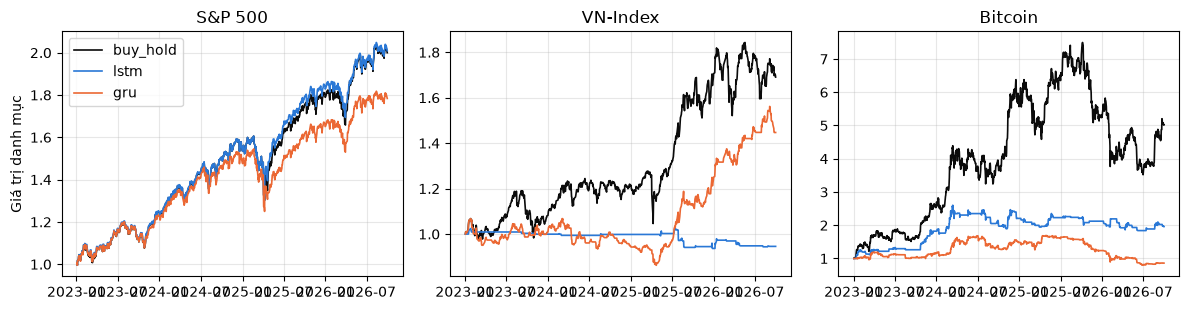

In [11]:
rows = []
for name in DATASETS:
    for key, b in analysis['backtest'][name].items():
        rows.append({'Chỉ số': NAMES[name], 'Chiến lược': key, 'Lợi suất năm trước phí': round(b['annual_return_gross'], 4),
                     'Lợi suất năm sau phí': round(b['annual_return'], 4), 'Sharpe': round(b['sharpe'], 2),
                     'Sụt giảm tối đa': round(b['max_drawdown'], 4), 'Thời gian nắm giữ': round(b['exposure'], 3),
                     'Số lần mua': b['entries']})
display(pd.DataFrame(rows))
fig, axes = plt.subplots(1, 3, figsize=(12, 3.2))
for ax, name in zip(axes, DATASETS):
    eq = analysis['equity'][name]
    dates = pd.to_datetime(eq['dates'])
    for key, color in (('buy_hold', '#0b0b0b'), ('lstm', '#2a78d6'), ('gru', '#eb6834')):
        ax.plot(dates, eq[key], color=color, lw=1.2, label=key)
    ax.set_title(NAMES[name]); ax.grid(alpha=.3)
axes[0].set_ylabel('Giá trị danh mục'); axes[0].legend()
plt.tight_layout(); plt.show()